### Rafael's Visualization

**Demographics**: birth_head_circumference_cm

**Daily Monitoring**: head_circumference_cm, respiratory_rate_bpm, oxygen_saturation

**Feeding & Hydration**: urine_output_count

**Risk Classification**: risk_level

In [1]:
# read the csv and please get these columns and just display each column use df
# csv name is: newborn_health_monitoring_with_risk.csv

import pandas as pd

# Read the CSV file
df = pd.read_csv('newborn_health_monitoring_with_risk.csv')
df


,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_kg,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
0,B001,Sara,Female,40.2,3.30,50.0,31.9,2024-12-10,1,3.28,...,98,Formula,11,9,0,4.2,7.0,Yes,Yes,At Risk
1,B001,Sara,Female,40.2,3.30,50.0,31.9,2024-12-11,2,3.35,...,99,Formula,11,5,2,10.6,NaN,No,No,At Risk
2,B001,Sara,Female,40.2,3.30,50.0,31.9,2024-12-12,3,3.35,...,97,Breastfeeding,7,6,5,9.8,NaN,No,No,Healthy
3,B001,Sara,Female,40.2,3.30,50.0,31.9,2024-12-13,4,3.48,...,97,Mixed,11,8,4,8.1,NaN,No,Yes,Healthy
4,B001,Sara,Female,40.2,3.30,50.0,31.9,2024-12-14,5,3.50,...,96,Breastfeeding,11,7,1,11.6,NaN,No,Yes,At Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,B100,Brian,Male,39.1,4.47,50.8,36.3,2025-03-31,26,5.29,...,96,Formula,8,7,4,4.0,NaN,No,Yes,Healthy
2996,B100,Brian,Male,39.1,4.47,50.8,36.3,2025-04-01,27,5.23,...,98,Breastfeeding,7,6,1,2.4,NaN,No,Yes,Healthy
2997,B100,Brian,Male,39.1,4.47,50.8,36.3,2025-04-02,28,5.29,...,98,Breastfeeding,8,4,1,3.6,NaN,No,Yes,Healthy
2998,B100,Brian,Male,39.1,4.47,50.8,36.3,2025-04-03,29,5.39,...,97,Mixed,10,5,2,2.2,NaN,No,No,Healthy


In [2]:
df.loc[100]

baby_id                              B004
name                               Donald
gender                               Male
gestational_age_weeks                38.2
birth_weight_kg                      2.87
birth_length_cm                      53.3
birth_head_circumference_cm          34.4
date                           2025-06-27
age_days                               11
weight_kg                            3.17
length_cm                            54.1
head_circumference_cm                34.6
temperature_c                        36.6
heart_rate_bpm                        133
respiratory_rate_bpm                   32
oxygen_saturation                      96
feeding_type                      Formula
feeding_frequency_per_day               8
urine_output_count                      7
stool_count                             2
jaundice_level_mg_dl                  2.1
apgar_score                           NaN
immunizations_done                     No
reflexes_normal                   

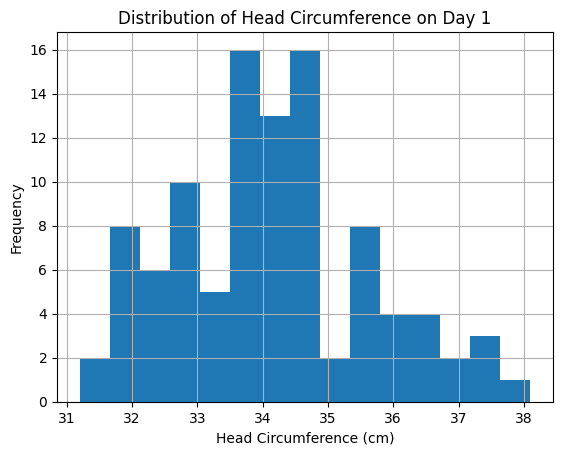

In [3]:
# So what we are going to do here is we are going to display each column that has daily monitoring as a hist and we can visualize the data, and explain
df[df['age_days'] == 1]["birth_head_circumference_cm"].hist(bins=15)
import matplotlib.pyplot as plt
plt.xlabel("Head Circumference (cm)")
plt.ylabel("Frequency")
plt.title("Distribution of Head Circumference on Day 1")
plt.show()

Data description - This particular column is the head circumference of each child at birth.

Data visualization & Distribution - As we can see above, the histogram shows the data peaks in the middle and slowly gets rarer left and right, thus causing me to believe this is more or less a gaussian.

Summary statistics Below:

Shapiro–Wilk Test:
  Statistic = 0.9811, p-value = 1.6120e-01

Kolmogorov–Smirnov Test:
  Statistic = 0.0864, p-value = 4.2102e-01


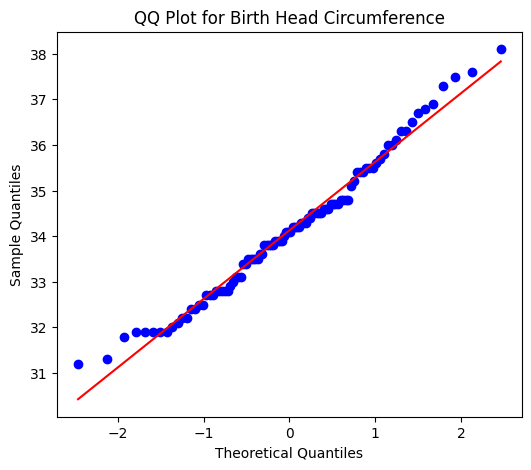


Shape Statistics:
  Skewness = 0.3681
  Kurtosis = -0.2130


In [4]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# assume your data column is a NumPy array or a pandas Series
x = df[df['age_days'] == 1]["birth_head_circumference_cm"].dropna().values

# 1. Shapiro–Wilk test (good for small–medium samples)
shapiro_stat, shapiro_p = stats.shapiro(x)
print("Shapiro–Wilk Test:")
print(f"  Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4e}")

# 2. Kolmogorov–Smirnov test against a fitted normal distribution
mu, sigma = np.mean(x), np.std(x, ddof=1)
ks_stat, ks_p = stats.kstest(x, 'norm', args=(mu, sigma))
print("\nKolmogorov–Smirnov Test:")
print(f"  Statistic = {ks_stat:.4f}, p-value = {ks_p:.4e}")

# 3. QQ plot (visual confirmation)
plt.figure(figsize=(6,5))
stats.probplot(x, dist="norm", plot=plt)
plt.title("QQ Plot for Birth Head Circumference")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

# 4. Skewness and Kurtosis (shape diagnostics)
skewness = stats.skew(x)
kurtosis = stats.kurtosis(x)
print("\nShape Statistics:")
print(f"  Skewness = {skewness:.4f}")
print(f"  Kurtosis = {kurtosis:.4f}")

In [5]:
subset = df[df['age_days'] == 1]["birth_head_circumference_cm"]

mean_val = subset.mean()
median_val = subset.median()
std_val = subset.std()
var_val = subset.var()
min_val = subset.min()
max_val = subset.max()
q1 = subset.quantile(0.25)
q3 = subset.quantile(0.75)

print(f"Mean (average head size): {mean_val:.2f} cm")
print(f"Median (middle value): {median_val:.2f} cm")
print(f"Standard Deviation (spread of sizes): {std_val:.2f} cm")
print(f"Variance (spread squared): {var_val:.2f} cm^2")
print(f"Minimum (smallest observed head size): {min_val:.2f} cm")
print(f"Maximum (largest observed head size): {max_val:.2f} cm")
print(f"Q1 (25th percentile - lower typical range): {q1:.2f} cm")
print(f"Q3 (75th percentile - upper typical range): {q3:.2f} cm")


Mean (average head size): 34.13 cm
Median (middle value): 34.10 cm
Standard Deviation (spread of sizes): 1.49 cm
Variance (spread squared): 2.23 cm^2
Minimum (smallest observed head size): 31.20 cm
Maximum (largest observed head size): 38.10 cm
Q1 (25th percentile - lower typical range): 32.98 cm
Q3 (75th percentile - upper typical range): 34.80 cm


In [6]:
# Ok now then we will visualize the series data for the following: head_circumference_cm, respiratory_rate_bpm, oxygen_saturation
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_longitudinal(df, col_name):
    plt.figure(figsize=(12, 6))
    plt.title(f"Mean {col_name} Over Time (With Confidence Band)")
    plt.xlabel("Age (days)")
    plt.ylabel(col_name)

    # Group by day
    grouped = df.groupby("age_days")[col_name]
    mean = grouped.mean()
    std = grouped.std()

    # --- Plot Mean Curve ---
    plt.plot(mean.index, mean.values, color="blue", label="Mean")

    # --- Plot Confidence Band ---
    plt.fill_between(mean.index,
                     mean - std,
                     mean + std,
                     alpha=0.2,
                     color="blue",
                     label="± 1 SD")

    plt.legend()
    plt.show()

    # --------- SPAGHETTI PLOT ----------
    plt.figure(figsize=(12, 6))
    plt.title(f"Individual Trajectories of {col_name}")
    plt.xlabel("Age (days)")
    plt.ylabel(col_name)

    for baby_id, sub in df.groupby("baby_id"):
        plt.plot(sub["age_days"], sub[col_name], alpha=0.1, color="gray")

    plt.show()


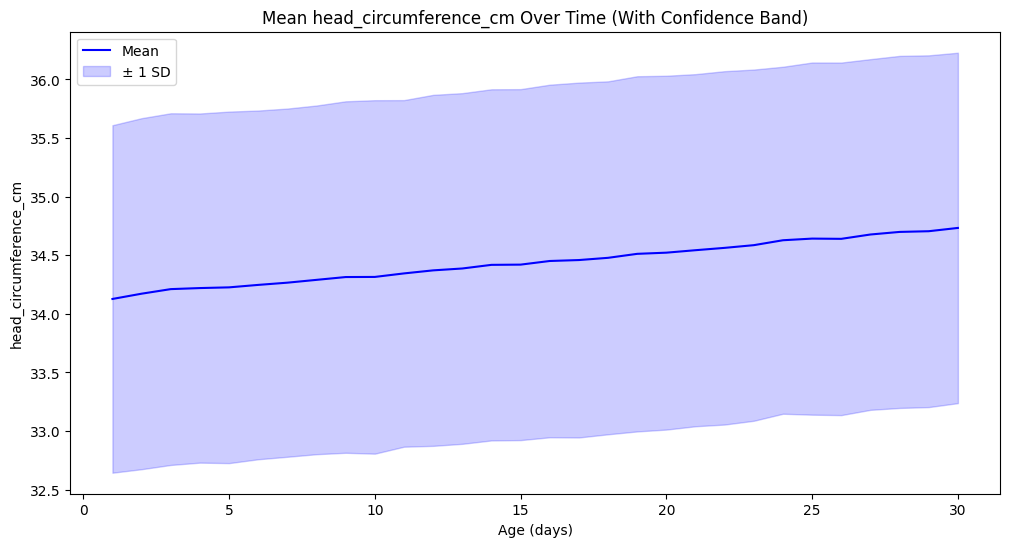

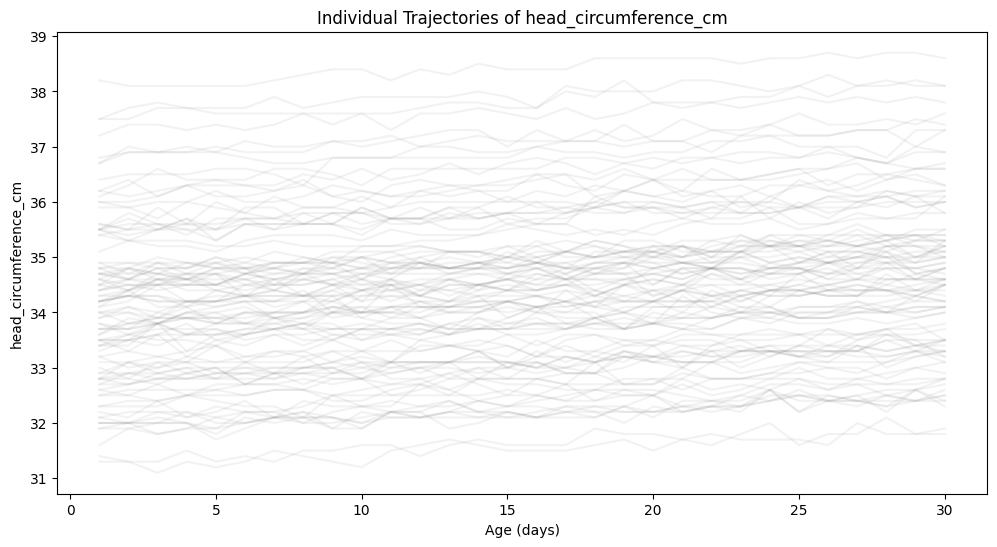

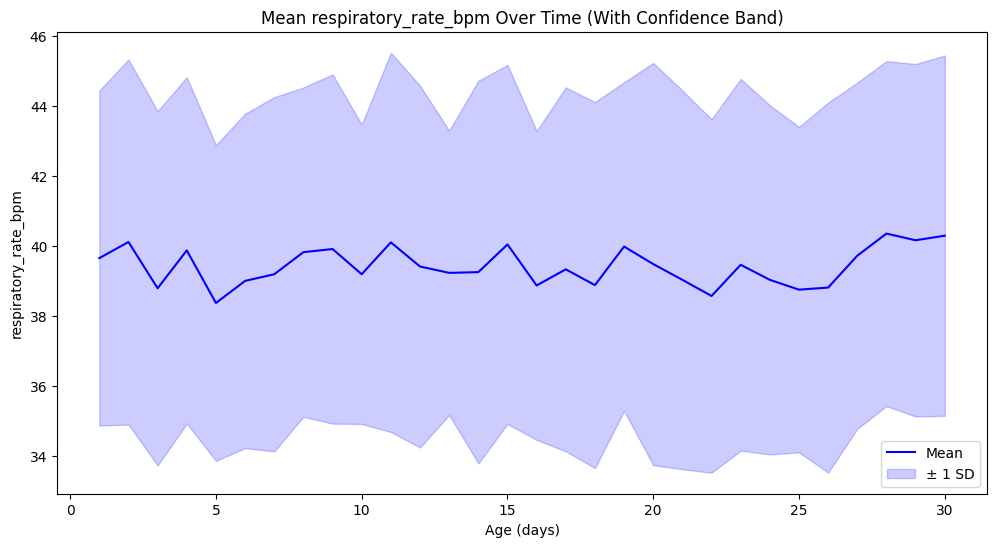

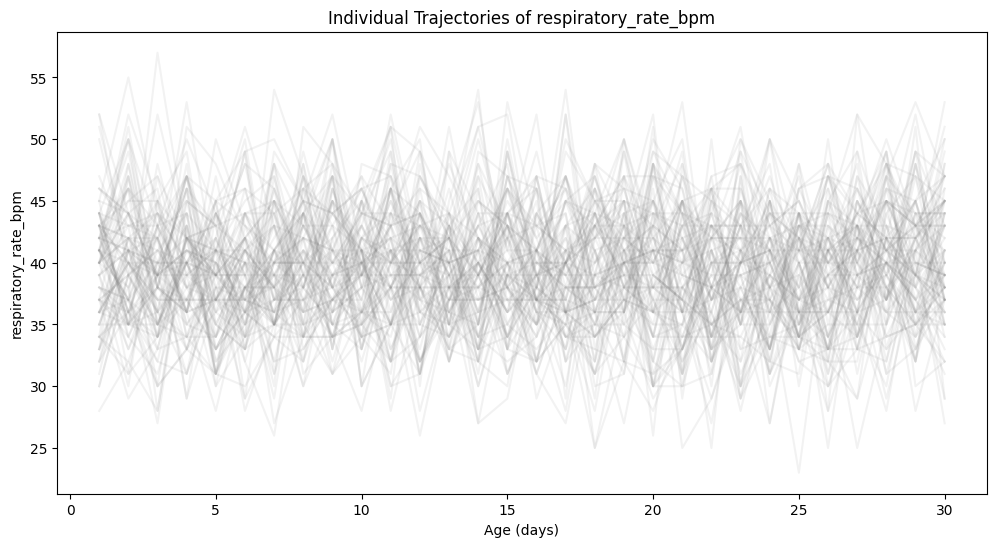

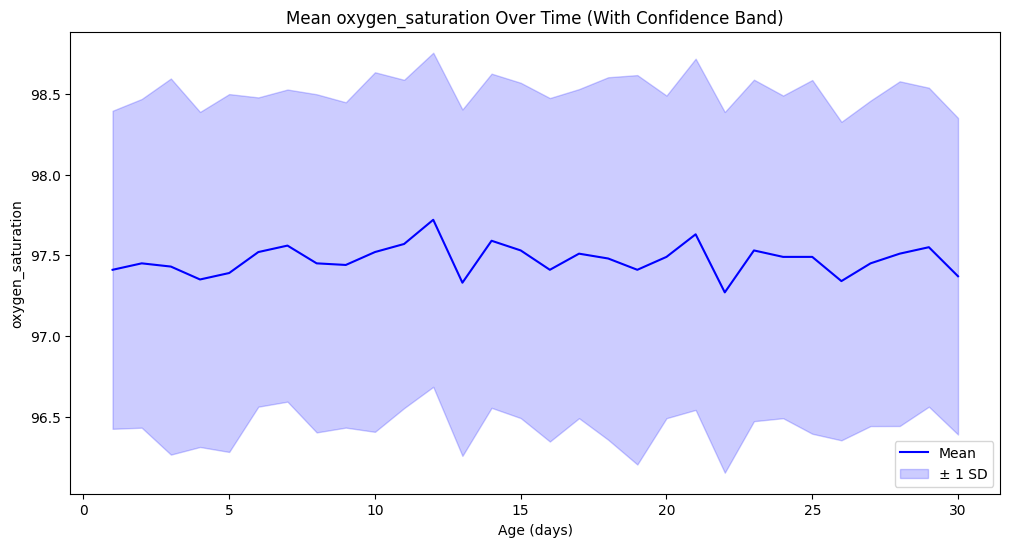

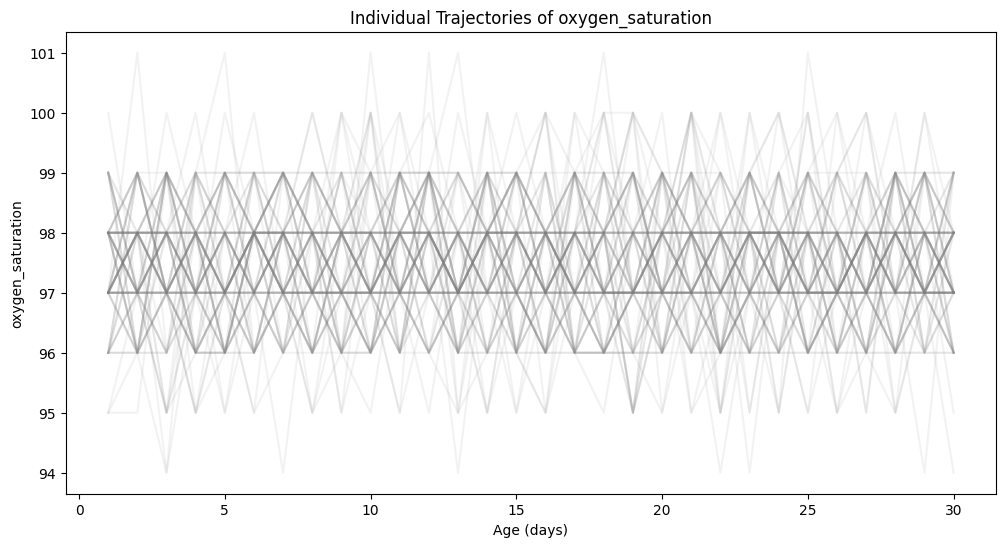

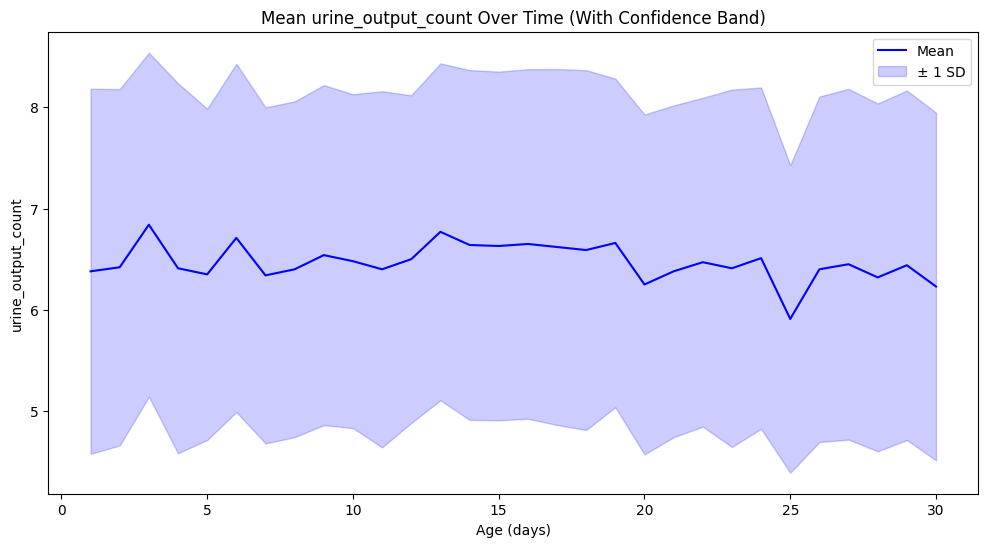

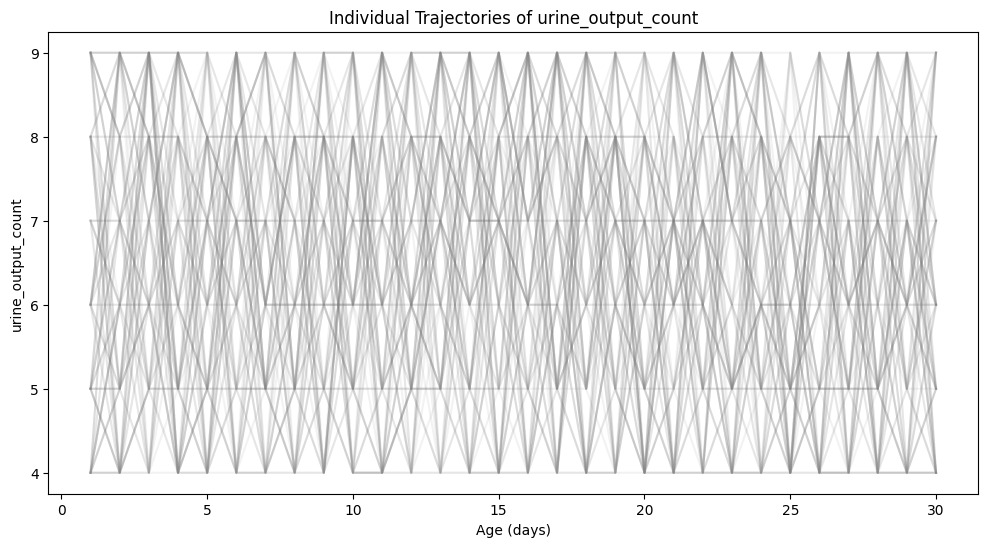

In [7]:
cols = ["head_circumference_cm", "respiratory_rate_bpm", "oxygen_saturation", "urine_output_count"]

for c in cols:
    plot_longitudinal(df, c)


Linear Model: head_circumference = 34.1272 + 0.0201 * age_days
R² = 0.9971


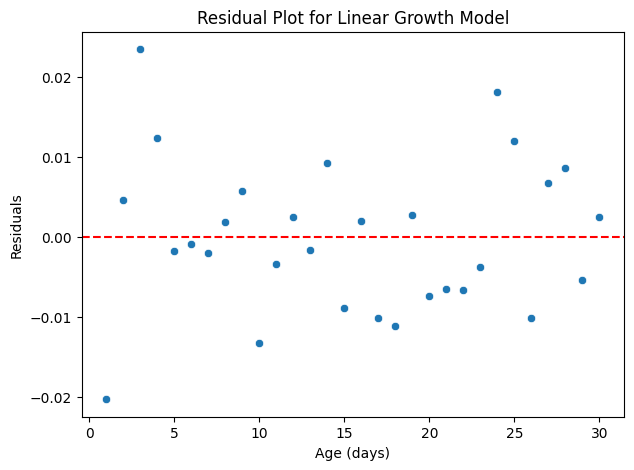

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

# Assume df has columns: ['age_days', 'head_circumference_cm']
# and contains repeated measurements for many infants.

# Compute mean per day (as you already did for your plot)
daily = df.groupby("age_days")["head_circumference_cm"].mean().reset_index()

X = daily["age_days"].values.reshape(-1, 1)
y = daily["head_circumference_cm"].values

# Fit linear model
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

print(f"Linear Model: head_circumference = {intercept:.4f} + {slope:.4f} * age_days")
print(f"R² = {r2:.4f}")

# Residuals
pred = model.predict(X)
residuals = y - pred

# Plot residuals to check for pattern
plt.figure(figsize=(7,5))
sns.scatterplot(x=daily["age_days"], y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot for Linear Growth Model")
plt.xlabel("Age (days)")
plt.ylabel("Residuals")
plt.show()


In [9]:
# Ok the next thing would be the risk level let's visualize it!

df["risk_level"].value_counts()

risk_level
Healthy    2602
At Risk     398
Name: count, dtype: int64

In [10]:
# Ok! This is interesting because this basically means that we have an inbalanced dataset when it comes to At Risk vs Healthy. When we train our regression or classification model we must ensure that it doesnt memorize to always say healthy as that can be a problem.

In [11]:
# Classifier Decision tree stuff

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

df_clean = df.copy()

# Drop identifiers
df_clean = df_clean.drop(columns=['baby_id', 'name', 'date'])

# Target encoding
df_clean['risk_level'] = df_clean['risk_level'].map({'Healthy': 0, 'At Risk': 1})

# Separate features and target
X = df_clean.drop(columns=['risk_level'])
y = df_clean['risk_level']

# Identify categorical columns
cat_cols = ['gender', 'feeding_type', 'immunizations_done', 'reflexes_normal']

# Build column transformer (One-hot encode categorical vars)
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [13]:
from sklearn.pipeline import Pipeline

model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",   # VERY IMPORTANT because data is imbalanced
    random_state=42
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', model)
])

clf.fit(X_train, y_train)


C:\Users\rsanz\AppData\Roaming\Python\Python312\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'feeding_type',
                                                   'immunizations_done',
                                                   'reflexes_normal'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

In [14]:
y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'At Risk']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       520
     At Risk       1.00      1.00      1.00        80

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Confusion Matrix:
[[520   0]
 [  0  80]]


In [15]:
# Get feature names after preprocessing
ohe = clf.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)
numeric_cols = [c for c in X.columns if c not in cat_cols]

all_features = list(cat_feature_names) + numeric_cols

importances = clf.named_steps['model'].feature_importances_

# Sort by importance
feat_imp = sorted(zip(all_features, importances), key=lambda x: x[1], reverse=True)

for feature, importance in feat_imp:
    print(f"{feature}: {importance:.4f}")


jaundice_level_mg_dl: 0.4895
heart_rate_bpm: 0.2639
oxygen_saturation: 0.2156
temperature_c: 0.0310
apgar_score: 0.0000
gender_Female: 0.0000
gender_Male: 0.0000
feeding_type_Breastfeeding: 0.0000
feeding_type_Formula: 0.0000
feeding_type_Mixed: 0.0000
immunizations_done_No: 0.0000
immunizations_done_Yes: 0.0000
reflexes_normal_No: 0.0000
reflexes_normal_Yes: 0.0000
gestational_age_weeks: 0.0000
birth_weight_kg: 0.0000
birth_length_cm: 0.0000
birth_head_circumference_cm: 0.0000
age_days: 0.0000
weight_kg: 0.0000
length_cm: 0.0000
head_circumference_cm: 0.0000
respiratory_rate_bpm: 0.0000
feeding_frequency_per_day: 0.0000
urine_output_count: 0.0000
stool_count: 0.0000


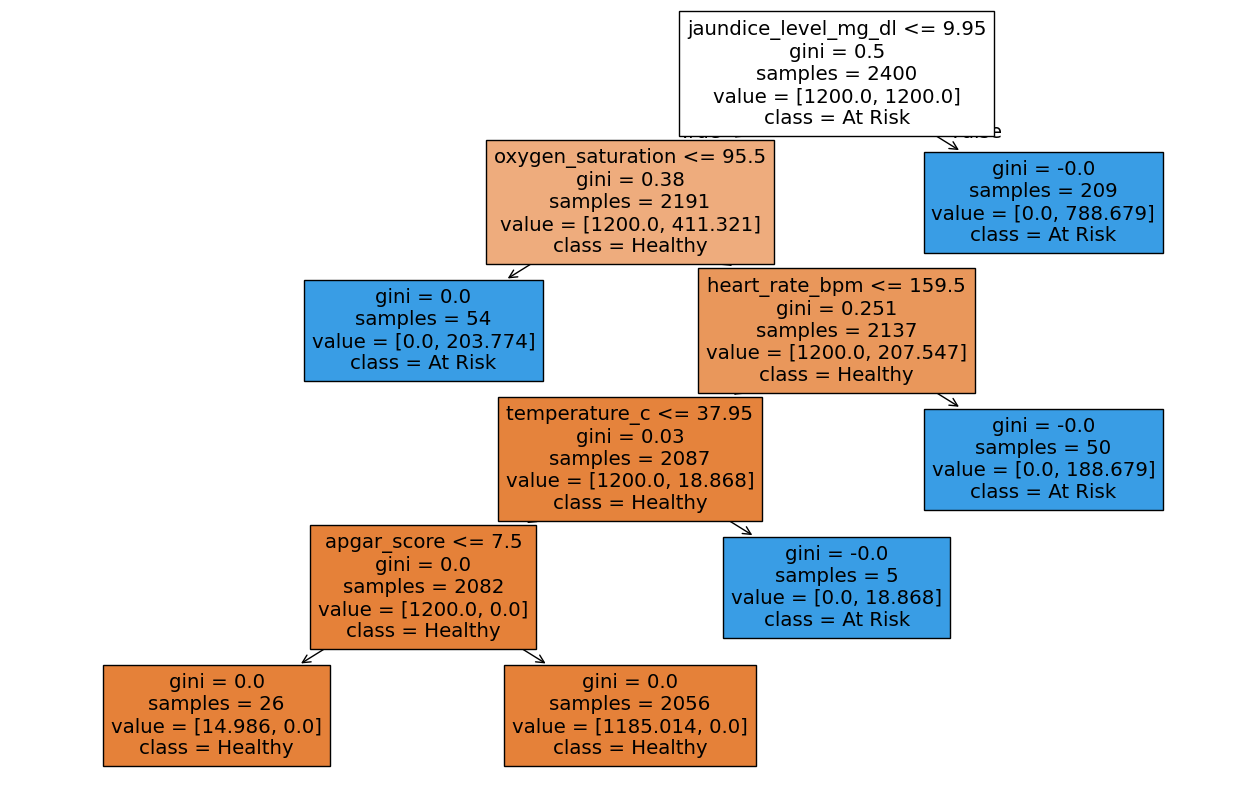

In [16]:
plt.figure(figsize=(16,10))
plot_tree(model, feature_names=all_features, class_names=['Healthy', 'At Risk'], filled=True)
plt.show()


In [17]:
# Decision tree without the cheating leakage variables

df_model = df.copy()

# Map target
df_model['risk_level'] = df_model['risk_level'].map({'Healthy': 0, 'At Risk': 1})

# Drop leakage columns
leak_cols = ['temperature_c', 'jaundice_level_mg_dl', 'oxygen_saturation', 'heart_rate_bpm']
df_model = df_model.drop(columns=leak_cols)

# Drop identifiers
df_model = df_model.drop(columns=['baby_id', 'name', 'date'])

X = df_model.drop(columns=['risk_level'])
y = df_model['risk_level']


In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = ['gender', 'feeding_type', 'immunizations_done', 'reflexes_normal']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', model)
])

clf.fit(X_train, y_train)


C:\Users\rsanz\AppData\Roaming\Python\Python312\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'feeding_type',
                                                   'immunizations_done',
                                                   'reflexes_normal'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

In [21]:
y_test

1916    0
1369    0
870     0
1227    0
1636    0
       ..
462     0
2109    0
1617    0
2259    0
1253    0
Name: risk_level, Length: 600, dtype: int64

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'At Risk']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.94      0.86      0.90       520
     At Risk       0.41      0.66      0.51        80

    accuracy                           0.83       600
   macro avg       0.68      0.76      0.70       600
weighted avg       0.87      0.83      0.85       600

Confusion Matrix:
[[445  75]
 [ 27  53]]


In [23]:
y_proba = clf.predict_proba(X_test)[:, 1]

# Choose a lower threshold, e.g. 0.30
threshold = 0.50
y_pred_adj = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_adj, target_names=['Healthy', 'At Risk']))
print(confusion_matrix(y_test, y_pred_adj))

              precision    recall  f1-score   support

     Healthy       0.94      0.86      0.90       520
     At Risk       0.41      0.66      0.51        80

    accuracy                           0.83       600
   macro avg       0.68      0.76      0.70       600
weighted avg       0.87      0.83      0.85       600

[[445  75]
 [ 27  53]]


In [24]:
# Extract feature names after encoding
ohe = clf.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

numeric_cols = [c for c in X.columns if c not in cat_cols]

all_features = list(cat_feature_names) + numeric_cols

importances = clf.named_steps['model'].feature_importances_

sorted_features = sorted(zip(all_features, importances), key=lambda x: x[1], reverse=True)

for feature, importance in sorted_features:
    print(f"{feature}: {importance:.4f}")


age_days: 0.7939
weight_kg: 0.0452
stool_count: 0.0278
birth_head_circumference_cm: 0.0266
length_cm: 0.0210
respiratory_rate_bpm: 0.0207
urine_output_count: 0.0204
feeding_frequency_per_day: 0.0139
birth_length_cm: 0.0099
apgar_score: 0.0070
gestational_age_weeks: 0.0067
birth_weight_kg: 0.0037
head_circumference_cm: 0.0034
reflexes_normal_No: 0.0000
gender_Female: 0.0000
gender_Male: 0.0000
feeding_type_Breastfeeding: 0.0000
feeding_type_Formula: 0.0000
feeding_type_Mixed: 0.0000
immunizations_done_No: 0.0000
immunizations_done_Yes: 0.0000
reflexes_normal_Yes: 0.0000


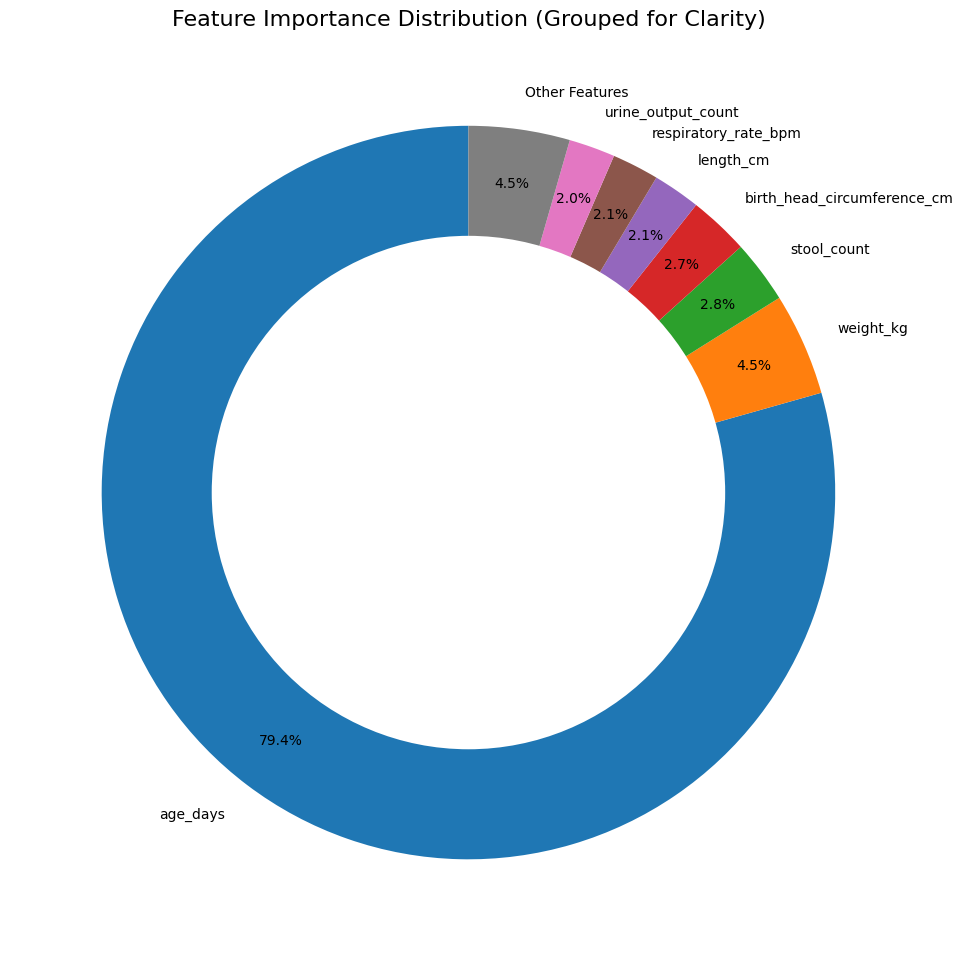

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Extract features + importances
ohe = clf.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

numeric_cols = [c for c in X.columns if c not in cat_cols]
all_features = list(cat_feature_names) + numeric_cols

importances = clf.named_steps['model'].feature_importances_

# Sort features by importance
sorted_features = sorted(zip(all_features, importances), key=lambda x: x[1], reverse=True)

# Threshold for grouping (5% = 0.05)
threshold = 0.02

main_features = []
main_scores = []
other_total = 0.0

for feature, score in sorted_features:
    if score >= threshold:
        main_features.append(feature)
        main_scores.append(score)
    else:
        other_total += score

# Add the "Other Features" group if needed
if other_total > 0:
    main_features.append("Other Features")
    main_scores.append(other_total)

# Normalize to percentages just for display clarity
scores_percent = (np.array(main_scores) / sum(main_scores)) * 100

# Pie chart
plt.figure(figsize=(10, 10))
plt.pie(
    scores_percent,
    labels=main_features,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)

# Donut style (optional)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Feature Importance Distribution (Grouped for Clarity)", fontsize=16)
plt.tight_layout()
plt.show()


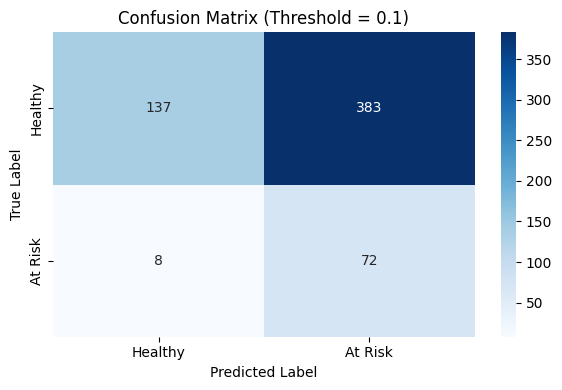

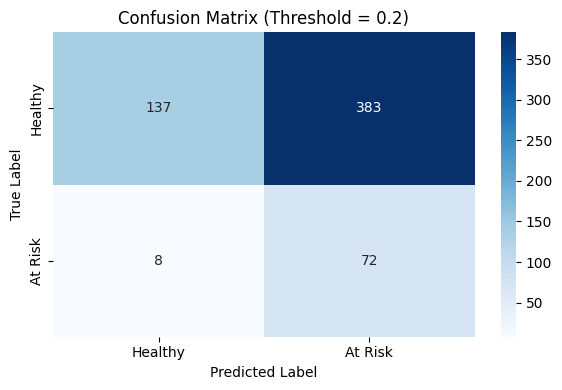

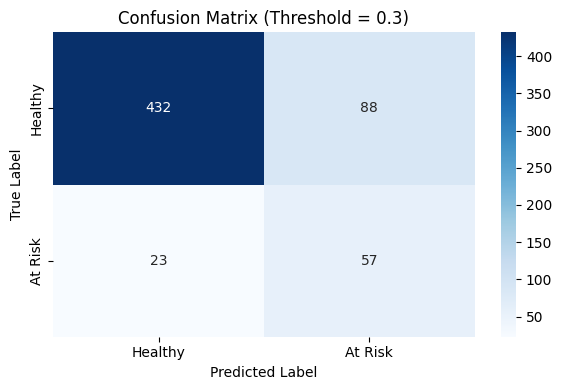

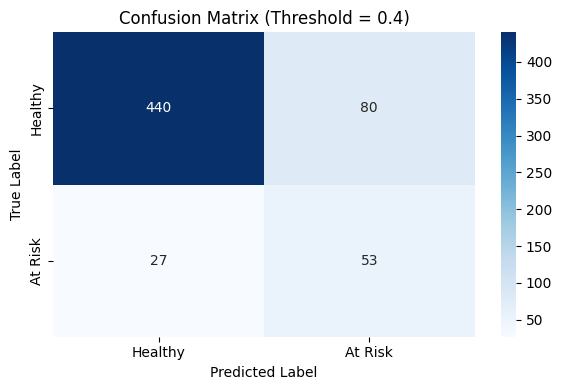

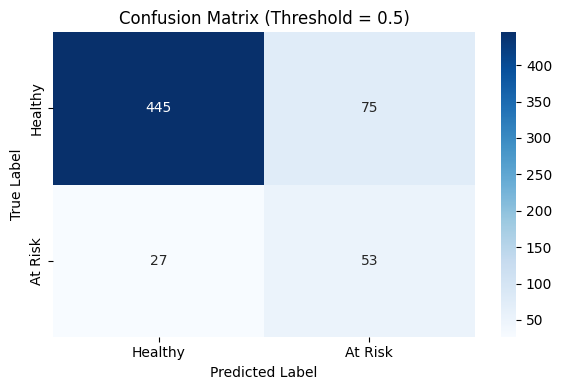

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

for t in thresholds:
    y_pred_adj = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_adj)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=['Healthy', 'At Risk'],
        yticklabels=['Healthy', 'At Risk']
    )
    
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Threshold = {t})")
    plt.tight_layout()
    plt.show()
